In [1]:
import time
import numpy as np
from numba import jit
from numba import njit
import numba as nb
from numba.typed import List
# Animation and plots:
import matplotlib.pyplot as plt
import matplotlib.artist as art
from matplotlib import cm
from IPython import display

from scipy import optimize

[5.55721208e-09 2.65927980e-05]
N for Unligated Fibrin=  1098.9958571929965
M for Unligated Fibrin=  236.38042668363832


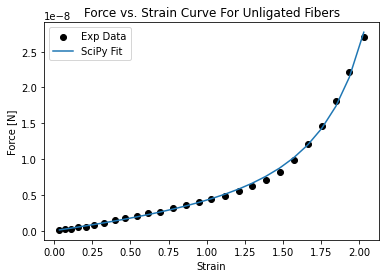

[-8.51975505e-17]
[1.57832155e-16]


In [2]:
#eps=2*len-1

def f_Ax(A,x,Eps,L_0):
    return A*((1/4)*(1-(Eps/(x/L_0)))**(-2)-(1/4)+(Eps/(x/L_0)))

def df_dA(x,Eps,L_0):
    return((1/4)*(1-(Eps*L_0/x))**(-2))-(1/4)+(Eps*L_0/x)

def df_dx(A,x,Eps,L_0):
    return(-A/2)*(1-(Eps*L_0/x))**(-3)*(Eps*L_0/x)-A*(Eps*L_0/(x**2))

def f_fit(Eps,A,x):
    L_0 = 10e3;
    return A*((1/4)*(1-(Eps/(x/L_0)))**(-2)-(1/4)+(Eps/(x/L_0)))

def L_fit(L,A,x):
    L_0 = 10e3;
    return A*((1/4)*(1-((L/x-1)/(x/L_0)))**(-2)-(1/4)+((L/x-1)/(x/L_0)))

Exp_Data = np.array([[0.0337423312883437, 0.12422360248447006],
[0.07055214723926395, 0.18633540372670865],
[0.1073619631901841, 0.24844720496894723],
[0.15337423312883447, 0.49689440993788736],
[0.20552147239263818, 0.559006211180126],
[0.2638036809815951, 0.8074534161490732],
[0.3282208588957056, 1.0559006211180133],
[0.39877300613496924, 1.4285714285714306],
[0.46319018404907986, 1.7391304347826093],
[0.5429447852760736, 2.049689440993788],
[0.6165644171779141, 2.4223602484472053],
[0.696319018404908, 2.6708074534161526],
[0.7791411042944785, 3.1677018633540364],
[0.861963190184049, 3.54037267080745],
[0.9478527607361962, 3.975155279503106],
[1.0306748466257667, 4.409937888198758],
[1.1196319018404906, 4.906832298136649],
[1.211656441717791, 5.52795031055901],
[1.2975460122699385, 6.273291925465841],
[1.3865030674846623, 7.142857142857142],
[1.4785276073619629, 8.26086956521739],
[1.5705521472392638, 9.813664596273291],
[1.6625766871165644, 12.049689440993788],
[1.754601226993865, 14.596273291925467],
[1.8466257668711654, 18.074534161490682],
[1.935582822085889, 22.173913043478258],
[2.0306748466257662, 27.01863354037267]])

L_0 = 10e-6; #original length of fiber [m]
l_0 = 45e-9; #original length of monomer [m]
l_p = 0.8e-9
l_c = 2.5*l_0; # predicted contour length of monomer [m]
k_B = 1.380649e-23 # Boltzmann Constant [J/K]
T = 293 # Temperature [K]


alpha = optimize.curve_fit(f_fit, xdata = Exp_Data[:,0] , ydata = Exp_Data[:,1],p0 = [5,2.5e+4])[0]
print(alpha*1e-9)

N = alpha[0]*1e-9/((k_B*T)/l_p)

print("N for Unligated Fibrin= ",str(N))

M = alpha[1]*1e-9/l_c

print("M for Unligated Fibrin= ",str(M))

Lengths = (alpha[1]*1e-9)*(Exp_Data[:,0]+1)

#fig = plt.figure()
#plt.plot(Lengths, L_fit(Lengths,alpha[0],alpha[1])*1e-9,label='SciPy Fit')

force_exp,ax = plt.subplots(1,1)
plt.title("Force vs. Strain Curve For Unligated Fibers")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(Exp_Data[:,0],Exp_Data[:,1]*1e-9,color = 'black',label = 'Exp Data')
plt.plot(Exp_Data[:,0], f_fit(Exp_Data[:,0],alpha[0],alpha[1])*1e-9,label='SciPy Fit')
ax.legend()
plt.show()
    

m,n = np.shape(Exp_Data)

All_ds_dA = np.zeros([m,1])
All_ds_dx = np.zeros([m,1])
        
for n in range(m):
    Eps = Exp_Data[n][0]
    F_n = Exp_Data[n][1]*1e-9
    
    ds_dA_n = (f_Ax(alpha[0],alpha[1],Eps,L_0)-F_n)*(df_dA(alpha[1],Eps,L_0))
    All_ds_dA[n] = ds_dA_n 
            
    ds_dx_n = (f_Ax(alpha[0],alpha[1],Eps,L_0)-F_n)*(df_dx(alpha[0],alpha[1],Eps,L_0))
    All_ds_dx[n] = ds_dx_n
        
Sum_ds_dA = sum(All_ds_dA)
Sum_ds_dx = sum(All_ds_dx)

print(Sum_ds_dA)
print(Sum_ds_dx)

[5.55721208e-09 2.65927980e-05]
N for Unligated Fibrin=  1098.9958571929965
M for Unligated Fibrin=  236.38042668363832


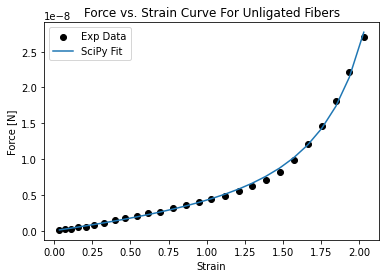

[-8.51975505e-17]
[1.57832155e-16]


In [5]:
#eps=2*len-1

def f_Ax(A,x,Eps,L_0):
    return A*((1/4)*(1-(Eps/(x/L_0)))**(-2)-(1/4)+(Eps/(x/L_0)))

def df_dA(x,Eps,L_0):
    return((1/4)*(1-(Eps*L_0/x))**(-2))-(1/4)+(Eps*L_0/x)

def df_dx(A,x,Eps,L_0):
    return(-A/2)*(1-(Eps*L_0/x))**(-3)*(Eps*L_0/x)-A*(Eps*L_0/(x**2))

def f_fit(Eps,A,x):
    L_0 = 10e3;
    return A*((1/4)*(1-(Eps/(x/L_0)))**(-2)-(1/4)+(Eps/(x/L_0)))

Exp_Data = np.array([[0.0337423312883437, 0.12422360248447006],
[0.07055214723926395, 0.18633540372670865],
[0.1073619631901841, 0.24844720496894723],
[0.15337423312883447, 0.49689440993788736],
[0.20552147239263818, 0.559006211180126],
[0.2638036809815951, 0.8074534161490732],
[0.3282208588957056, 1.0559006211180133],
[0.39877300613496924, 1.4285714285714306],
[0.46319018404907986, 1.7391304347826093],
[0.5429447852760736, 2.049689440993788],
[0.6165644171779141, 2.4223602484472053],
[0.696319018404908, 2.6708074534161526],
[0.7791411042944785, 3.1677018633540364],
[0.861963190184049, 3.54037267080745],
[0.9478527607361962, 3.975155279503106],
[1.0306748466257667, 4.409937888198758],
[1.1196319018404906, 4.906832298136649],
[1.211656441717791, 5.52795031055901],
[1.2975460122699385, 6.273291925465841],
[1.3865030674846623, 7.142857142857142],
[1.4785276073619629, 8.26086956521739],
[1.5705521472392638, 9.813664596273291],
[1.6625766871165644, 12.049689440993788],
[1.754601226993865, 14.596273291925467],
[1.8466257668711654, 18.074534161490682],
[1.935582822085889, 22.173913043478258],
[2.0306748466257662, 27.01863354037267]])

L_0 = 10e-6; #original length of fiber [m]
l_0 = 45e-9; #original length of monomer [m]
l_p = 0.8e-9
l_c = 2.5*l_0; # predicted contour length of monomer [m]
k_B = 1.380649e-23 # Boltzmann Constant [J/K]
T = 293 # Temperature [K]


alpha = optimize.curve_fit(f_fit, xdata = Exp_Data[:,0] , ydata = Exp_Data[:,1],p0 = [5,2.5e+4])[0]
print(alpha*1e-9)

N = alpha[0]*1e-9/((k_B*T)/l_p)

print("N for Unligated Fibrin= ",str(N))

M = alpha[1]*1e-9/l_c

print("M for Unligated Fibrin= ",str(M))

#x_range = np.linspace(-2, 2, 100);
#fig = plt.figure()
#plt.plot(x_range, f_fit(x_range,alpha[0],alpha[1])*1e-9,label='SciPy Fit')

force_exp,ax = plt.subplots(1,1)
plt.title("Force vs. Strain Curve For Unligated Fibers")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(Exp_Data[:,0],Exp_Data[:,1]*1e-9,color = 'black',label = 'Exp Data')
plt.plot(Exp_Data[:,0], f_fit(Exp_Data[:,0],alpha[0],alpha[1])*1e-9,label='SciPy Fit')
ax.legend()
plt.show()
    

m,n = np.shape(Exp_Data)

All_ds_dA = np.zeros([m,1])
All_ds_dx = np.zeros([m,1])
        
for n in range(m):
    Eps = Exp_Data[n][0]
    F_n = Exp_Data[n][1]*1e-9
    
    ds_dA_n = (f_Ax(alpha[0],alpha[1],Eps,L_0)-F_n)*(df_dA(alpha[1],Eps,L_0))
    All_ds_dA[n] = ds_dA_n 
            
    ds_dx_n = (f_Ax(alpha[0],alpha[1],Eps,L_0)-F_n)*(df_dx(alpha[0],alpha[1],Eps,L_0))
    All_ds_dx[n] = ds_dx_n
        
Sum_ds_dA = sum(All_ds_dA)
Sum_ds_dx = sum(All_ds_dx)

print(Sum_ds_dA)
print(Sum_ds_dx)

[4.13563517e-09 2.33674892e-05]
N for ligated Fibrin=  817.8643983114526
M for ligated Fibrin=  207.71101483685172


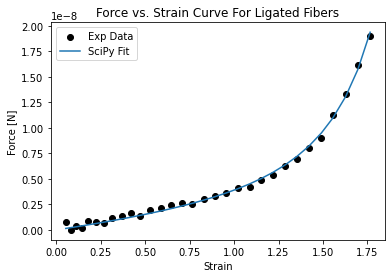

[-6.75823623e-17]
[9.31733054e-17]


In [6]:
# ligated Experimental Data from Houser Experiment Collected From Image Analysis:

def f_Ax(A,x,Eps,L_0):
    return A*((1/4)*(1-(Eps/(x/L_0)))**(-2)-(1/4)+(Eps/(x/L_0)))

def df_dA(x,Eps,L_0):
    return((1/4)*(1-(Eps*L_0/x))**(-2))-(1/4)+(Eps*L_0/x)

def df_dx(A,x,Eps,L_0):
    return(-A/2)*(1-(Eps*L_0/x))**(-3)*(Eps*L_0/x)-A*(Eps*L_0/(x**2))

def f_fit(Eps,A,x):
    L_0 = 10e3;
    return A*((1/4)*(1-(Eps/(x/L_0)))**(-2)-(1/4)+(Eps/(x/L_0)))

Exp_Data = np.array([[0.054216867469879526, 0.7272727272727266],
[0.0813253012048194, 0],
[0.11144578313253006, 0.4242424242424221],
[0.14759036144578308, 0.18181818181818343],
[0.1807228915662651, 0.8484848484848477],
[0.22590361445783136, 0.787878787878789],
[0.27108433734939763, 0.6666666666666643],
[0.3162650602409638, 1.1515151515151523],
[0.3674698795180723, 1.393939393939391],
[0.4186746987951807, 1.6363636363636367],
[0.47289156626506024, 1.393939393939391],
[0.5271084337349397, 1.9393939393939412],
[0.5873493975903614, 2.1212121212121176],
[0.6445783132530121, 2.424242424242422],
[0.707831325301205, 2.6060606060606055],
[0.7650602409638554, 2.5454545454545467],
[0.8283132530120481, 3.0303030303030276],
[0.8945783132530121, 3.333333333333332],
[0.9548192771084338, 3.636363636363633],
[1.0210843373493976, 4.060606060606059],
[1.0873493975903614, 4.18181818181818],
[1.150602409638554, 4.848484848484848],
[1.216867469879518, 5.393939393939391],
[1.2861445783132528, 6.242424242424239],
[1.3524096385542168, 6.90909090909091],
[1.4216867469879517, 8.060606060606059],
[1.4909638554216866, 8.969696969696969],
[1.5542168674698793, 11.27272727272727],
[1.6265060240963853, 13.333333333333332],
[1.6957831325301203, 16.18181818181818],
[1.7650602409638552, 19.03030303030303]])

L_0 = 10e-6; #original length of fiber [m]
l_0 = 45e-9; #original length of monomer [m]
l_p = 0.8e-9
l_c = 2.5*l_0; # predicted contour length of monomer [m]
k_B = 1.380649e-23 # Boltzmann Constant [J/K]
T = 293 # Temperature [K]


alpha = optimize.curve_fit(f_fit, xdata = Exp_Data[:,0] , ydata = Exp_Data[:,1],p0 = [5,2.5e+4])[0]
print(alpha*1e-9)

N = alpha[0]*1e-9/((k_B*T)/l_p)

print("N for ligated Fibrin= ",str(N))

M = alpha[1]*1e-9/l_c

print("M for ligated Fibrin= ",str(M))

force_exp,ax = plt.subplots(1,1)
plt.title("Force vs. Strain Curve For Ligated Fibers")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(Exp_Data[:,0],Exp_Data[:,1]*1e-9,color = 'black',label = 'Exp Data')
plt.plot(Exp_Data[:,0], f_fit(Exp_Data[:,0],alpha[0],alpha[1])*1e-9,label='SciPy Fit')
ax.legend()
plt.show()
    

m,n = np.shape(Exp_Data)

All_ds_dA = np.zeros([m,1])
All_ds_dx = np.zeros([m,1])
        
for n in range(m):
    Eps = Exp_Data[n][0]
    F_n = Exp_Data[n][1]*1e-9
    
    ds_dA_n = (f_Ax(alpha[0],alpha[1],Eps,L_0)-F_n)*(df_dA(alpha[1],Eps,L_0))
    All_ds_dA[n] = ds_dA_n 
            
    ds_dx_n = (f_Ax(alpha[0],alpha[1],Eps,L_0)-F_n)*(df_dx(alpha[0],alpha[1],Eps,L_0))
    All_ds_dx[n] = ds_dx_n
        
Sum_ds_dA = sum(All_ds_dA)
Sum_ds_dx = sum(All_ds_dx)

print(Sum_ds_dA)
print(Sum_ds_dx)